**WEEK 5 SIMULATION NOTEBOOK**

Continuing on from Week 4, this week, the objectives are: 

1. Simulating the behaviour of the $\Pi$ matrices as $\varepsilon$ tends to zero, and how the error changes. 
2. Simulating the output of non-decaying signals. 
3. Simulaitng the output when $S_{11} = S_{22} = 0$

Some theoretical objectives are: 

1. Finding conditions for $\Pi_{z1}$, $\Pi_{z2}$, $\Pi_{x2}$. How do we mathematically explain their behaviour as epsilon changes?
2. What happens when $S_{22}$ is NOT Hurwitz?
3. Controllability and Observability, explore the connections? 

In terms of simulation, the main thing that needs to change is to be able to implement varying values of $\varepsilon$


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as la


Let us make it more general than before: 
\begin{align}
\dot{x} &= A_{11} x + A_{12} z + B_1 u \in \mathbb{R}^n \\
\varepsilon \dot{z} &= A_{21} x + A_{22} z + B_2 u \in \mathbb{R}^m
\end{align}

\begin{align}
\dot{w}_1 &= S_{11} w_1 + S_{12} w_2 \in \mathbb{R}^{N_{g1}} \\
\varepsilon \dot{w}_2 &= S_{21} w_1 + S_{22} w_1 \in \mathbb{R}^{N_{g2}}
\end{align}

\begin{equation}
u = L_{g1} w_1 + L_{g2} w_2 \in \mathbb{R}
\end{equation}

\begin{equation}
y = C_1 x + C_2 z \in \mathbb{R}
\end{equation}

Below is a general framework for solving the system dynamics for whatever system/ signal we might have. 


In [3]:
from dataclasses import dataclass

@dataclass
class SystemParams:
    n: int
    m: int
    Ng1: int
    Ng2: int
    A11: np.ndarray
    A12: np.ndarray
    A21: np.ndarray
    A22: np.ndarray
    S11: np.ndarray
    S12: np.ndarray
    S21: np.ndarray
    S22: np.ndarray
    Lg1: np.ndarray
    Lg2: np.ndarray
    B1: np.ndarray
    B2: np.ndarray
    epsilon: float

def combined_system(t, state, p: SystemParams):
    # Unpack states
    x = state[:p.n]
    z = state[p.n: p.n + p.m]
    w1 = state[p.n+p.m:p.n+p.m+p.Ng1]
    w2 = state[p.n+p.m+p.Ng1:p.n+p.m+p.Ng1+p.Ng2]

    # Input
    u = p.Lg1 @ w1 + p.Lg2 @ w2

    # Dynamics
    dx = p.A11 @ x + p.A12 @ z + p.B1.flatten() * u
    dz = (p.A21 @ x + p.A22 @ z + p.B2.flatten() * u) / p.epsilon
    dw1 = p.S11 @ w1 + p.S12 @ w2
    dw2 = (p.S21 @ w1 + p.S22 @ w2) / p.epsilon

    return np.concatenate([dx, dz, dw1, dw2])

For the system, we'll use the car suspension model once again. 
\begin{equation}
\dot{x}_1 = x_2 - z_2
\end{equation}

\begin{equation}
\dot{x}_2 = -x_1 - \beta x_2 + \beta z_2 + u
\end{equation}

\begin{equation}
\varepsilon \dot{z}_1 = z_2
\end{equation}

\begin{equation}
\varepsilon \dot{z}_2 = \alpha x_1 - \alpha \beta (z_2 - x_2) - z_1 - \alpha u 
\end{equation}

For the Signal, we want to try a non-decaying oscillatory signal:
So we'll go for something like this: 

\begin{equation}
S_{11} = 
\begin{bmatrix}
0.1 & -1 \\
1 & 0.1
\end{bmatrix}
\end{equation}

\begin{equation}
S_{12} = 
\begin{bmatrix}
0 & 0.1 \\
0.1 & 0
\end{bmatrix}
\end{equation}


\begin{equation}
S_{21} = 
\begin{bmatrix}
0 & -0.1 \\
-0.1 & 0
\end{bmatrix}
\end{equation}


\begin{equation}
S_{22} = 
\begin{bmatrix}
0.2 & 2 \\
2 & 0.2
\end{bmatrix}
\end{equation}


[2.         1.73205081]
[1.41421356 1.        ]
[[2.         1.73205081 1.41421356 1.        ]]


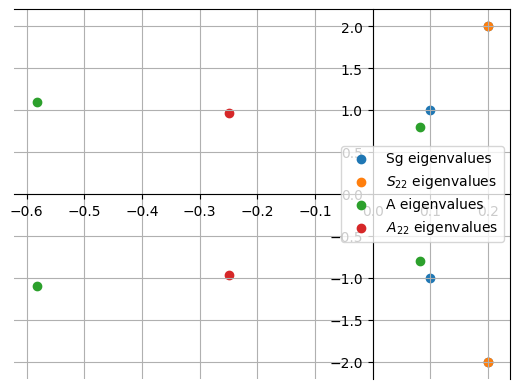

In [4]:
# SETTING SYSTEM PARAMETERS

alpha = 1.0
beta = 0.5
A11 = np.array([[0., 1.],
                [-1., -beta]])
A12 = np.array([[0.,0.],
                [0.,beta]])
A21 = np.array([[0.,0.],
                [alpha, alpha * beta]])
A22 = np.array([[0., 1.0],
                [-1., -alpha * beta]])
B1 = np.array([[0.],
               [1.0]])
B2 = np.array([[0.],
               [-alpha]])

S11 = np.array([[0.1, -1.],
                [1. , 0.1]])
S12 = np.array([[0. , 0.1],
                [0.1 , 0.]])
S21 = np.array([[0., -0.1],
                [-0.1 , 0.]])
S22 = np.array([[0.2, -2.],
                [2. , 0.2]])

Sg = np.block([[S11,S12],
              [S21, S22]])

A_full0 = np.block([[A11, A12],
                    [A21, A22]])


def eigenvalue_list_creator(Sg):
    Re = []
    Im = []
    for z in np.linalg.eigvals(Sg):
        Re.append(np.real(z))
        Im.append(np.imag(z))
    return Re, Im

Re_Sg, Im_Sg = eigenvalue_list_creator(Sg)
Re_A, Im_A = eigenvalue_list_creator(A_full0)
Re_A22, Im_A22 = eigenvalue_list_creator(A22)
Re_S22, Im_S22 = eigenvalue_list_creator(S22)

fig, ax = plt.subplots()
ax.scatter(Re_Sg, Im_Sg, label = 'Sg eigenvalues')
ax.scatter(Re_S22, Im_S22, label = r'$S_{22}$ eigenvalues')
ax.scatter(Re_A, Im_A, label = 'A eigenvalues')
ax.scatter(Re_A22, Im_A22, label = r'$A_{22}$ eigenvalues')
ax.spines['left'].set_position('zero')  # Move y-axis to x=0
ax.spines['bottom'].set_position('zero')  # Move x-axis to y=0

ax.legend()
ax.grid(True)
ax.scatter
    



#initial conditions
state0 = [1., 1., 2.,0.5, 0.5, 0.5, 0.1, 0.1]

n = len(A11)
m = len(A22)
Ng1 = len(S11)
Ng2 = len(S22)

# same Lg as week 4
Lg = np.array([[(4.0-i)**0.5 for i in range(4)]])
Lg1 = Lg[0][:2]
Lg2 = Lg[0][2:]

print(Lg1)
print(Lg2)
print(Lg)

Epsilon loop

Let's say:
\begin{align}
C_1 &= \begin{bmatrix} 1 & 1 \end{bmatrix} \\
C_2 &= \begin{bmatrix} 1 & 1 \end{bmatrix}
\end{align}


In [5]:
from mpl_toolkits.mplot3d import Axes3D

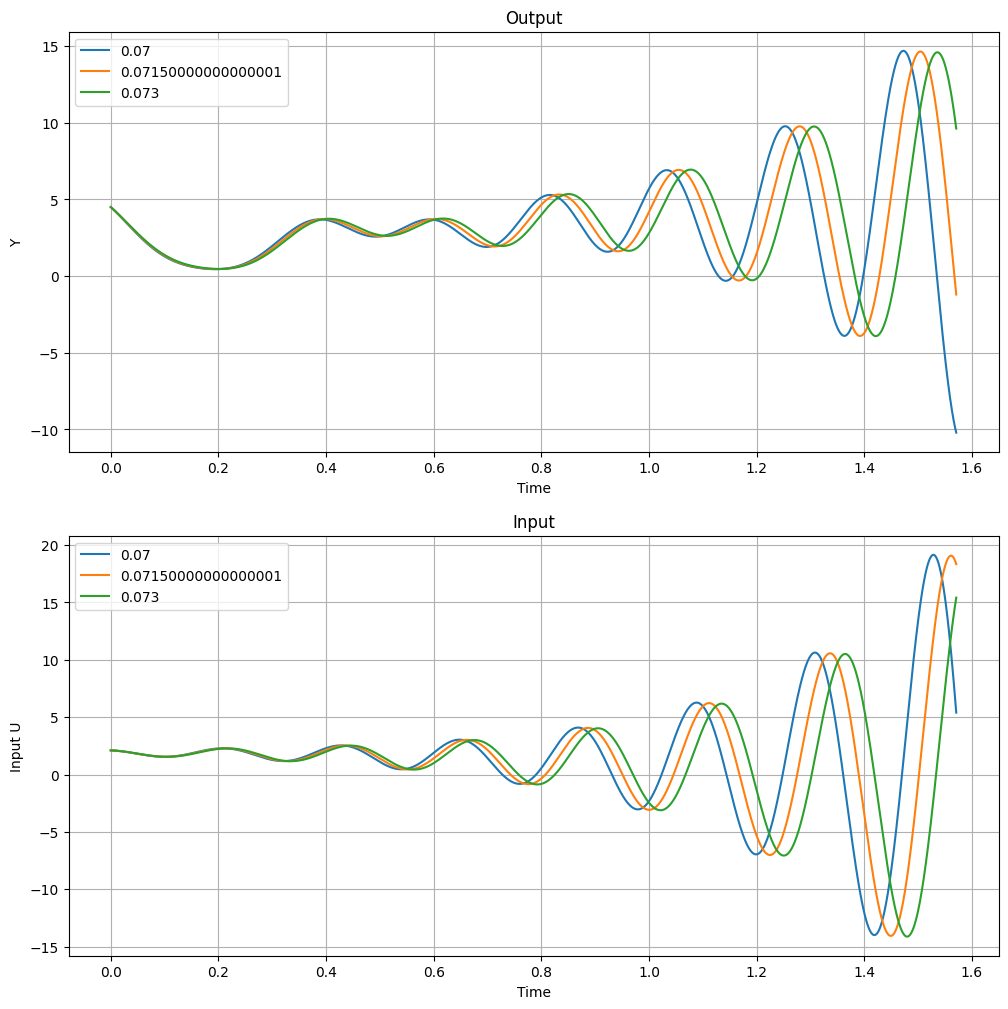

In [6]:
# Time span
t_span = (0., 0.5*np.pi)
t_eval = np.linspace(t_span[0], t_span[1], 100000)

C1 = np.array([[1.0 , 1. ]])
C2 = np.array([[1. ,1. ]])

Y_all = []

# array of small values between 0 and 1 for epsilon
epsilon_list = np.linspace(0.07, 0.073, 3)


plt.figure( figsize = (12,12))
for epsilon in epsilon_list:
    parameters = SystemParams(n, m, Ng1, Ng2, A11, A12, A21, A22,
                              S11, S12, S21, S22, Lg1, Lg2, B1, B2, epsilon)
    
    # solving the system for the given value in epsilon
    sol = solve_ivp(
        lambda t, state: combined_system(t, state, parameters),
        t_span, 
        state0, 
        t_eval = t_eval, 
        method = 'Radau'
    )
    
    X = sol.y[:n, :]
    Z = sol.y[n: n + m, :]
    W1 = sol.y[ n+m: n+m+Ng1, :]
    W2 = sol.y[ n+m+Ng1: n+m+Ng1+Ng2, :]
    U = Lg1 @ W1 + Lg2 @ W2

    Y = C1 @ X + C2 @ Z
    Y_all.append(Y.flatten())

    plt.subplot(2,1,1)
    plt.plot(sol.t, Y.flatten(), label = str(epsilon))
    plt.grid(True)
    plt.title("Output")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Y")

    plt.subplot(2,1,2)
    plt.plot(sol.t, U.flatten(), label=str(epsilon))
    plt.grid(True)
    plt.title("Input")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Input U")

    
# 3D plotting
# Y_all = np.array(Y_all)

# # For plotting, pick one output dimension (say first one

# T, E = np.meshgrid(t_eval, epsilon_list)

# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# ax.plot_surface(T, E, Y_all, cmap='viridis')

# ax.set_xlabel("Time t")
# ax.set_ylabel("Epsilon")
# ax.set_zlabel("Y")

plt.show()



    

    

Definitely not stable. 
Oscillatory signal. 

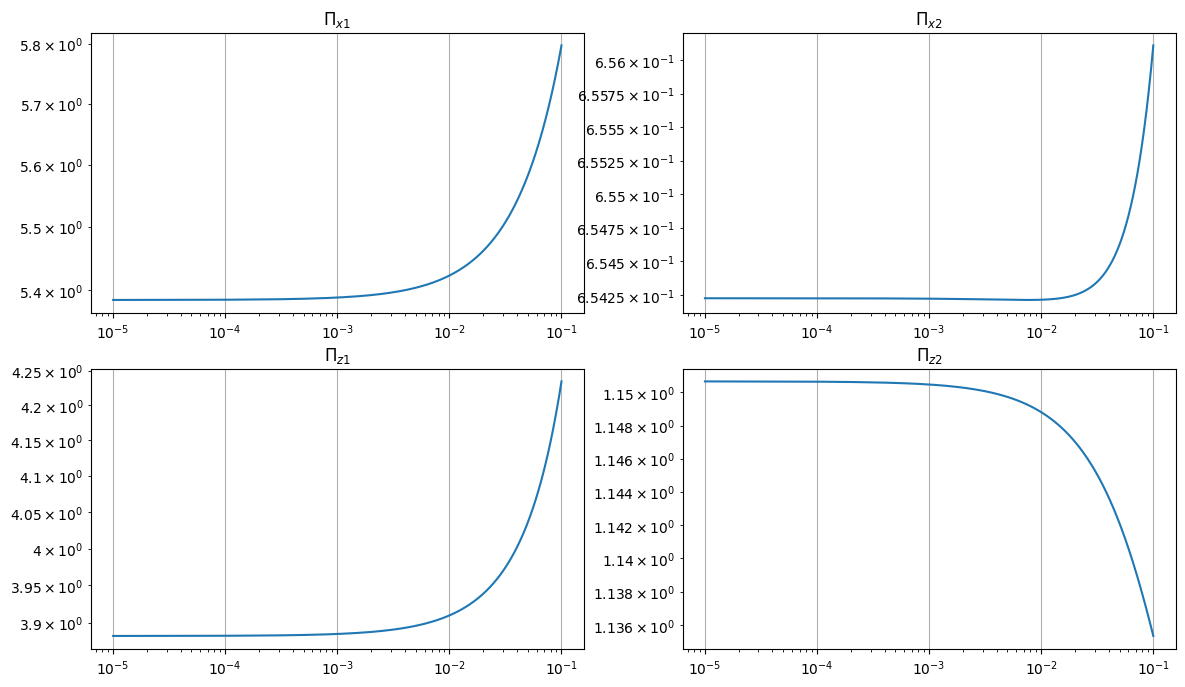

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

epsilon_list2 = np.linspace(1e-5, 0.1, 1000)
Pi_x1_lst = []
Pi_x2_lst = []
Pi_z1_lst = []
Pi_z2_lst = []
for epsilon in epsilon_list2:
    parameters = SystemParams(n, m, Ng1, Ng2, A11, A12, A21, A22,
                              S11, S12, S21, S22, Lg1, Lg2, B1, B2, epsilon)
    
    k = 1/epsilon
    A_full = np.block([[A11, A12],
                       [k * A21, k * A22]])
    B_full = np.block([[B1],
                       [k * B2]])
    
    Sg = np.block([[S11, S12],
                   [k * S21, k * S22]])
    
    Pi_full = la.solve_sylvester( A_full, -Sg, -(B_full @ Lg))


    Pi_x1 = Pi_full[:2, :2]
    Pi_x2 = Pi_full[0:2, 2:4]
    Pi_z1 = Pi_full[2:4, 0:2]
    Pi_z2 = Pi_full[2: , 2:]

    Pi_x1_lst.append(la.norm(Pi_x1))
    Pi_x2_lst.append(la.norm(Pi_x2)/epsilon)
    Pi_z1_lst.append(la.norm(Pi_z1))
    Pi_z2_lst.append(la.norm(Pi_z2))


# norm(Pi_x1) graph
axs[0,0].loglog(epsilon_list2.flatten(), Pi_x1_lst)
axs[0,0].set_title(r'$\Pi_{x1}$')
axs[0,0].grid(True)

# norm(Pi_x2) graph
axs[0,1].loglog(epsilon_list2.flatten(), Pi_x2_lst)
axs[0,1].set_title(r'$\Pi_{x2}$')
axs[0,1].grid(True)

# norm(Pi_z1) graph
axs[1,0].loglog(epsilon_list2.flatten(), Pi_z1_lst)
axs[1,0].set_title(r'$\Pi_{z1}$')
axs[1,0].grid(True)

# norm(Pi_z2) graph
axs[1,1].loglog(epsilon_list2.flatten(), Pi_z2_lst)
axs[1,1].set_title(r'$\Pi_{z2}$')
axs[1,1].grid(True)


plt.show()

Do we still have convergence for an unstable input? 

$\Pi_{x1}$ converges to a non-zero constant. So does $\Pi_{z2}$. $\Pi_{x2}$ heads to 0 as expected. 


Let us compare $\tilde{\Pi}$ and $\Pi_{x1}$

<>:26: SyntaxWarning: invalid escape sequence '\P'
<>:33: SyntaxWarning: invalid escape sequence '\P'
<>:34: SyntaxWarning: invalid escape sequence '\P'
<>:40: SyntaxWarning: invalid escape sequence '\P'
<>:41: SyntaxWarning: invalid escape sequence '\P'
<>:26: SyntaxWarning: invalid escape sequence '\P'
<>:33: SyntaxWarning: invalid escape sequence '\P'
<>:34: SyntaxWarning: invalid escape sequence '\P'
<>:40: SyntaxWarning: invalid escape sequence '\P'
<>:41: SyntaxWarning: invalid escape sequence '\P'
C:\Users\yoonj\AppData\Local\Temp\ipykernel_44632\2942233598.py:26: SyntaxWarning: invalid escape sequence '\P'
  plt.loglog(epsilon_flat, Pi_red_line.flatten(), label = '$\Pi_{red}$')
C:\Users\yoonj\AppData\Local\Temp\ipykernel_44632\2942233598.py:33: SyntaxWarning: invalid escape sequence '\P'
  plt.loglog(epsilon_flat, Pi_z2_line, label = '$\Pi_{z2}^{(0)}$')
C:\Users\yoonj\AppData\Local\Temp\ipykernel_44632\2942233598.py:34: SyntaxWarning: invalid escape sequence '\P'
  plt.loglog(e

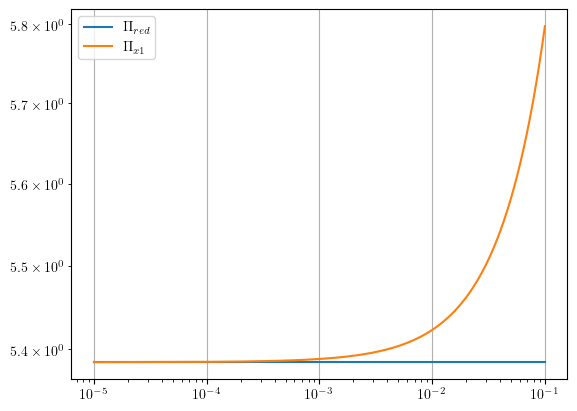

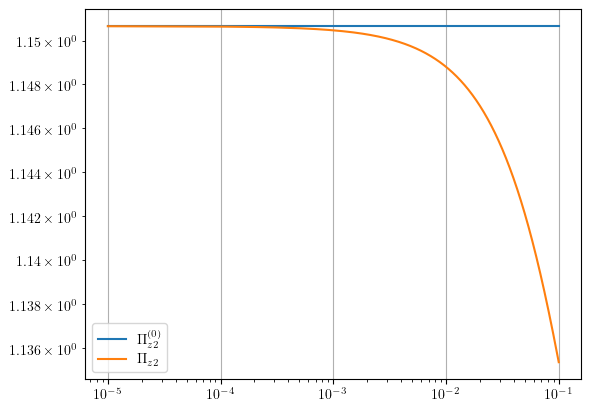

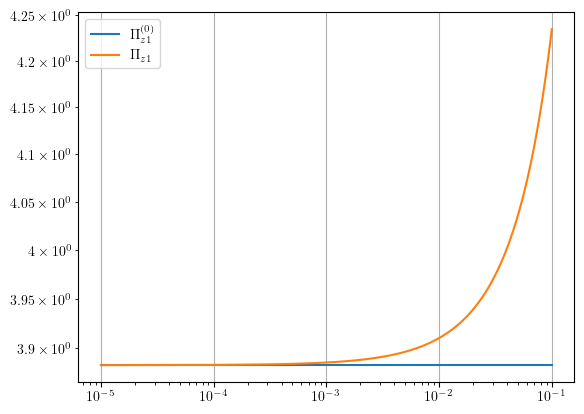

In [8]:
A22inv = la.inv(A22)
S22inv = la.inv(S22)
A_red = (A11 - (A12 @ A22inv @ A21))
B_red = (B1 - (A12  @ A22inv @ B2))
Sg_red = (S11 - (S12 @ S22inv @ S21))
Lg_red = [(Lg1 - (Lg2 @ S22inv @ S21))]
# Solving for Pi for reduced system
Pi_red = la.solve_sylvester( A_red, -Sg_red, -(B_red @ Lg_red))

# Solving for Pi for A22 thing
X = B2 @ np.array([Lg2])
Pi_z2_0 = la.solve_sylvester( A22, -S22, -(X))

# Solving for zeroth order approx of Pi_z1

Pi_z1_0 = A22inv @ (Pi_z2_0 @ S21 - (B2 @ np.array([Lg1])) - (A21 @ Pi_red))


# forming lines 
Pi_red_line = np.array([la.norm(Pi_red) for i in range(len(epsilon_list2))])
Pi_z2_line = np.array([la.norm(Pi_z2_0) for i in range(len(epsilon_list2))])
Pi_z1_line = np.array([la.norm(Pi_z1_0) for i in range(len(epsilon_list2))])
epsilon_flat = epsilon_list2.flatten()

plt.figure(1)
plt.loglog(epsilon_flat, Pi_red_line.flatten(), label = '$\Pi_{red}$')
plt.loglog(epsilon_flat, Pi_x1_lst, label = r'$\Pi_{x1}$')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(2)
plt.loglog(epsilon_flat, Pi_z2_line, label = '$\Pi_{z2}^{(0)}$')
plt.loglog(epsilon_flat, Pi_z2_lst, label = '$\Pi_{z2}$')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(3)
plt.loglog(epsilon_flat, Pi_z1_line, label = '$\Pi_{z1}^{(0)}$')
plt.loglog(epsilon_flat, Pi_z1_lst, label = '$\Pi_{z1}$')
plt.legend()
plt.grid(True)
plt.show()


Interestingly, we still have convergence with an unstable system. We have convergence even when S_22 is not stable.


Let us explore what happens when $S_{22} = 0$ and $S_{11} = 0$

Is the **ultimate** goal to be able to realise unstable LSPS?

In [9]:
matrix = np.array([[11,12,13,14],
                   [21,22,23,24],
                   [31,32,33,34],
                   [41,42,43,44]])
print(matrix[2:4, 0:2])
print(matrix[0:2, 2:4])


[[31 32]
 [41 42]]
[[13 14]
 [23 24]]


Now suppose that $S_{11}$ and $S_{22}$ are both 0

Simulating the input and output response: 

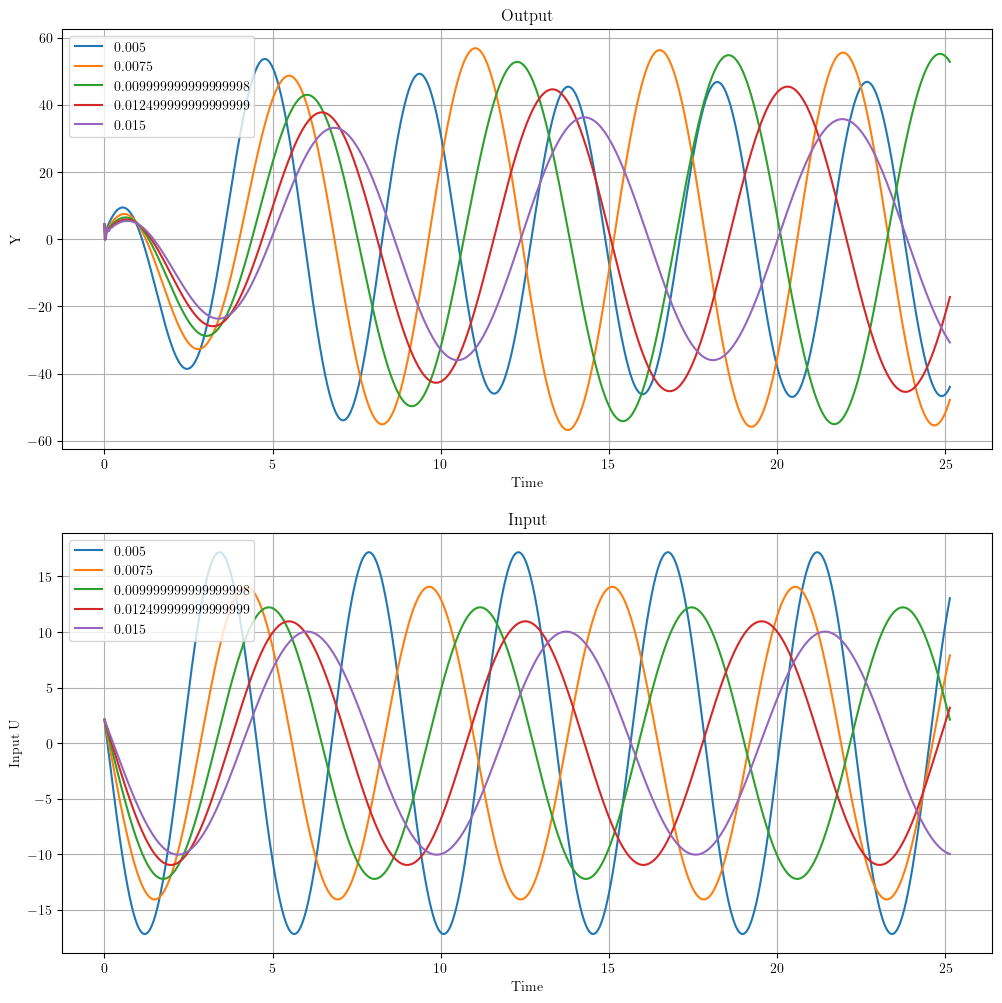

In [10]:
S11_2 = np.zeros((2,2))
S12_2 = np.array([[0. , 0.1],
                [0.1 , 0.]])
S21_2 = np.array([[0., -0.1],
                [-0.1 , 0.]])
S22_2 = np.zeros((2,2))


t_span = (0., 8.0*np.pi)
t_eval = np.linspace(t_span[0], t_span[1], 10000)

epsilon_list = np.linspace(0.005, 0.015, 5)

plt.figure( figsize = (12,12))
for epsilon in epsilon_list:
    parameters = SystemParams(n, m, Ng1, Ng2, A11, A12, A21, A22,
                              S11_2, S12_2, S21_2, S22_2, Lg1, Lg2, B1, B2, epsilon)
    
    # solving the system for the given value in epsilon
    sol = solve_ivp(
        lambda t, state: combined_system(t, state, parameters),
        t_span, 
        state0, 
        t_eval = t_eval, 
        method = 'Radau'
    )
    
    X = sol.y[:n, :]
    Z = sol.y[n: n + m, :]
    W1 = sol.y[ n+m: n+m+Ng1, :]
    W2 = sol.y[ n+m+Ng1: n+m+Ng1+Ng2, :]
    U = Lg1 @ W1 + Lg2 @ W2

    Y = C1 @ X + C2 @ Z
    Y_all.append(Y.flatten())

    plt.subplot(2,1,1)
    plt.plot(sol.t, Y.flatten(), label = str(epsilon))
    plt.grid(True)
    plt.title("Output")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Y")

    plt.subplot(2,1,2)
    plt.plot(sol.t, U.flatten(), label=str(epsilon))
    plt.grid(True)
    plt.title("Input")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Input U")


1.7320508075688774


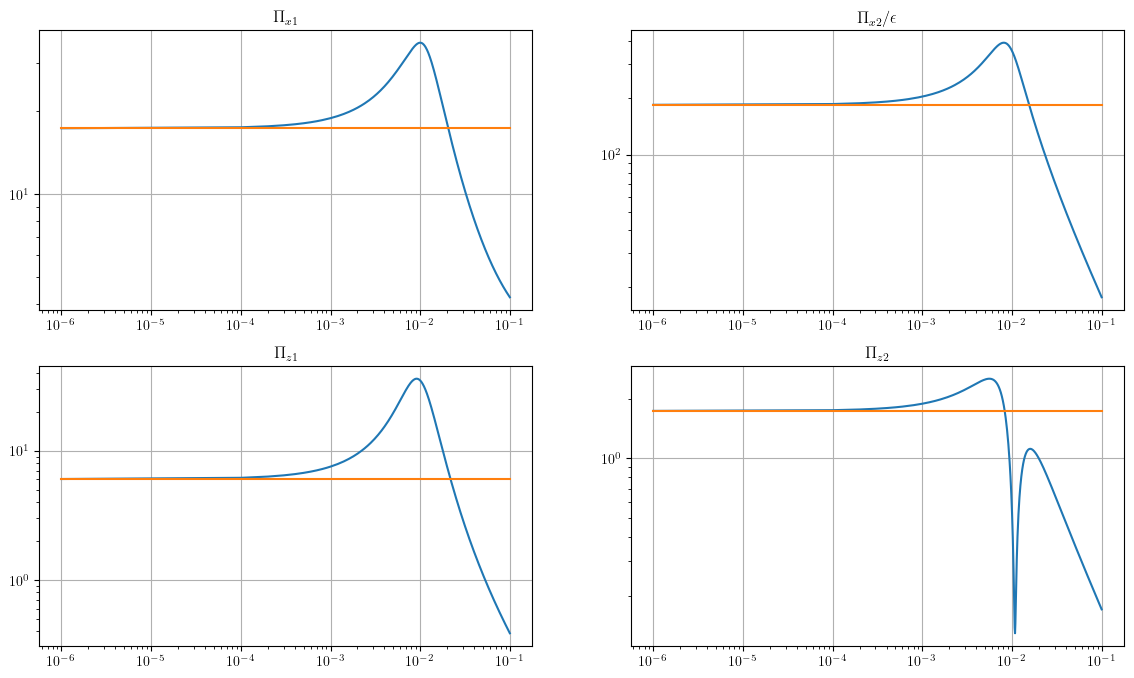

In [28]:

fig, axs = plt.subplots(2, 2, figsize=(14, 8))
epsilon_list2 = np.linspace(1e-6, 0.1, 1000)
Pi_x1_lst2 = []
Pi_x2_lst2 = []
Pi_z1_lst2 = []
Pi_z2_lst2 = []
for epsilon in epsilon_list2:
    parameters = SystemParams(n, m, Ng1, Ng2, A11, A12, A21, A22,
                              S11_2, S12_2, S21_2, S22_2, Lg1, Lg2, B1, B2, epsilon)
    
    k = 1/epsilon
    A_full = np.block([[A11, A12],
                       [k * A21, k * A22]])
    B_full = np.block([[B1],
                       [k * B2]])
    
    Sg2 = np.block([[np.zeros((2,2)), S12_2],
                   [k* S21_2, np.zeros((2,2))]])
    
    Pi_full = la.solve_sylvester( A_full, -Sg2, -(B_full @ Lg))


    Pi_x1 = Pi_full[:2, :2]
    Pi_x2 = Pi_full[0:2, 2:4]
    Pi_z1 = Pi_full[2:4, 0:2]
    Pi_z2 = Pi_full[2: , 2:]

    Pi_x1_lst2.append(la.norm(Pi_x1))
    Pi_x2_lst2.append(la.norm(Pi_x2)/epsilon)
    Pi_z1_lst2.append(la.norm(Pi_z1))
    Pi_z2_lst2.append(la.norm(Pi_z2))


# Pi_z2 zeroth order estimate: 
Pi_z2_0_new = - A22inv @ B2 @ Lg2.reshape(1,2)
print(la.norm(Pi_z2_0_new))
Pi_z2_0_list = np.array([la.norm(Pi_z2_0_new) for i in range(len(epsilon_list2))])


# Pi_x1_0 zeroth order estimate: 
Pi_x1_0 = (-A12 @ A22inv @ B2 @ np.array([Lg2]) + B1 @ np.array([Lg2])) @ la.inv(S12)
Pi_x1_0_list = np.array([la.norm(Pi_x1_0) for i in range(len(epsilon_list2))])

#Pi_z1_0 zeroth order estimate
Pi_z1_0 = A22inv @ (Pi_z2_0_new @ S21 - A21 @ Pi_x1_0 - (B2 @ np.array([Lg1])))
Pi_z1_0_list = np.array([la.norm(Pi_z1_0) for i in range(len(epsilon_list2))])

#Pi_x2_1 first order
Pi_x2_1 = (A11 @ Pi_x1_0
           + A12 @ Pi_z1_0
           + B1 @ np.array([Lg1])) @ la.inv(S12)
Pi_x2_1_list = np.array([la.norm(Pi_x2_1) for i in range(len(epsilon_list2))])

# norm(Pi_x1) graph
axs[0,0].loglog(epsilon_list2.flatten(), Pi_x1_lst2)
axs[0,0].loglog(epsilon_list2.flatten(), Pi_x1_0_list)
axs[0,0].set_title(r'$\Pi_{x1}$')
axs[0,0].grid(True)

# norm(Pi_x2) graph
axs[0,1].loglog(epsilon_list2.flatten(), Pi_x2_lst2)
axs[0,1].loglog(epsilon_list2.flatten(), Pi_x2_1_list)
axs[0,1].set_title(r'$\Pi_{x2} / \epsilon $')
axs[0,1].grid(True)

# norm(Pi_z1) graph
axs[1,0].loglog(epsilon_list2.flatten(), Pi_z1_lst2)
axs[1,0].loglog(epsilon_list2.flatten(), Pi_z1_0_list)
axs[1,0].set_title(r'$\Pi_{z1}$')
axs[1,0].grid(True)

# norm(Pi_z2) graph
axs[1,1].loglog(epsilon_list2.flatten(), Pi_z2_lst2)
axs[1,1].loglog(epsilon_list2.flatten(), Pi_z2_0_list)
axs[1,1].set_title(r'$\Pi_{z2}$')
axs[1,1].grid(True)


plt.show()